## 🧠 10 — Artificial Neural Network (ANN)

**What it does:** Learns complex patterns through layers of
interconnected neurons with weights adjusted via backpropagation.  
**Best used when:** Large datasets, complex non-linear patterns.  
**Dataset:** Bank Customer Churn (Kaggle)  
**Algorithm type:** Deep Learning → Binary Classification  
**Key concepts:** Layers, neurons, activation functions,
backpropagation, epochs  
**⚠️ Feature scaling required!**  
**Model saved as:** `ann_model.keras`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
df = pd.read_csv('Churn_Modelling.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:", df.isnull().sum().sum())
df.head()

Shape: (10000, 14)

Columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Missing values: 0


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print("Churn distribution:")
print(df['Exited'].value_counts())
print(f"\nChurn rate: {df['Exited'].mean()*100:.1f}%")

Churn distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.4%


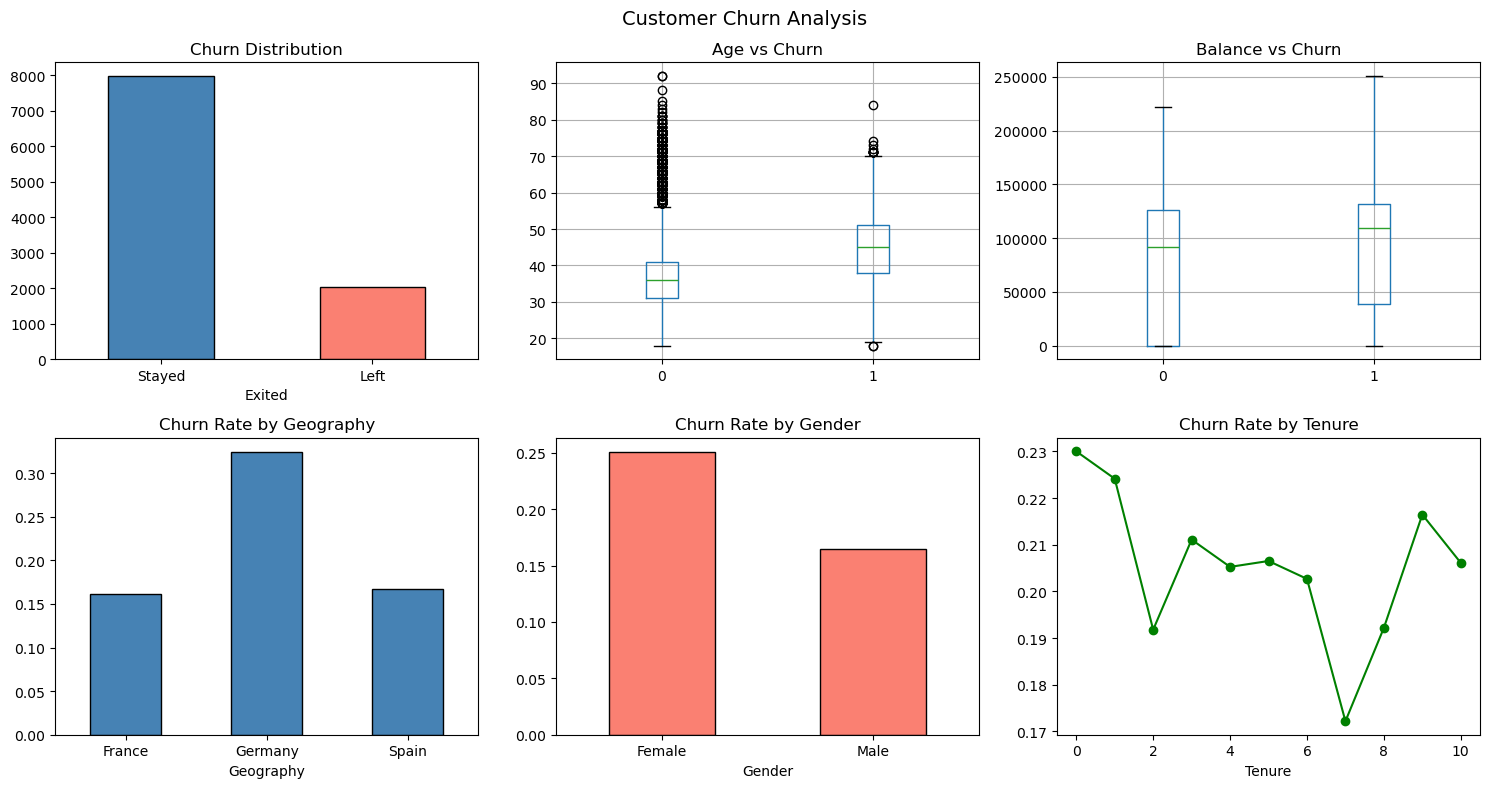

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

# Churn distribution
df['Exited'].value_counts().plot(kind='bar',
    ax=axes[0][0], color=['steelblue','salmon'],
    edgecolor='black')
axes[0][0].set_title('Churn Distribution')
axes[0][0].set_xticklabels(['Stayed','Left'], rotation=0)

# Age vs Churn
df.boxplot(column='Age', by='Exited', ax=axes[0][1])
axes[0][1].set_title('Age vs Churn')
axes[0][1].set_xlabel('')

# Balance vs Churn
df.boxplot(column='Balance', by='Exited', ax=axes[0][2])
axes[0][2].set_title('Balance vs Churn')
axes[0][2].set_xlabel('')

# Geography vs Churn
df.groupby('Geography')['Exited'].mean().plot(
    kind='bar', ax=axes[1][0],
    color='steelblue', edgecolor='black')
axes[1][0].set_title('Churn Rate by Geography')
axes[1][0].set_xticklabels(axes[1][0].get_xticklabels(),
                            rotation=0)

# Gender vs Churn
df.groupby('Gender')['Exited'].mean().plot(
    kind='bar', ax=axes[1][1],
    color='salmon', edgecolor='black')
axes[1][1].set_title('Churn Rate by Gender')
axes[1][1].set_xticklabels(axes[1][1].get_xticklabels(),
                            rotation=0)

# Tenure vs Churn
df.groupby('Tenure')['Exited'].mean().plot(
    kind='line', ax=axes[1][2],
    color='green', marker='o')
axes[1][2].set_title('Churn Rate by Tenure')

plt.suptitle('Customer Churn Analysis', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Drop irrelevant columns
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)

# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One-hot encode Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

print("Shape after encoding:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape after encoding: (10000, 12)
Columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [6]:
# Split features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features:", X_train.shape[1])

Training samples: 8000
Testing samples: 2000
Features: 11


In [7]:
# Build the neural network
model = keras.Sequential([
    # Input layer
    layers.Dense(64, activation='relu',
                 input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.3),

    # Hidden layer 1
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    # Hidden layer 2
    layers.Dense(16, activation='relu'),

    # Output layer — sigmoid for binary classification
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Early stopping — stops if no improvement
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete ✅")

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7798 - loss: 0.5026 - val_accuracy: 0.7987 - val_loss: 0.4279
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8000 - loss: 0.4481 - val_accuracy: 0.8300 - val_loss: 0.4106
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8153 - loss: 0.4268 - val_accuracy: 0.8512 - val_loss: 0.3861
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8352 - loss: 0.3993 - val_accuracy: 0.8487 - val_loss: 0.3641
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8444 - loss: 0.3784 - val_accuracy: 0.8506 - val_loss: 0.3569
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8487 - loss: 0.3691 - val_accuracy: 0.8506 - val_loss: 0.3514
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8477 - loss: 0.3672 - val_accuracy: 0.8537 - val_loss: 0.3509
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8477 - loss: 0.3667 - val_acc

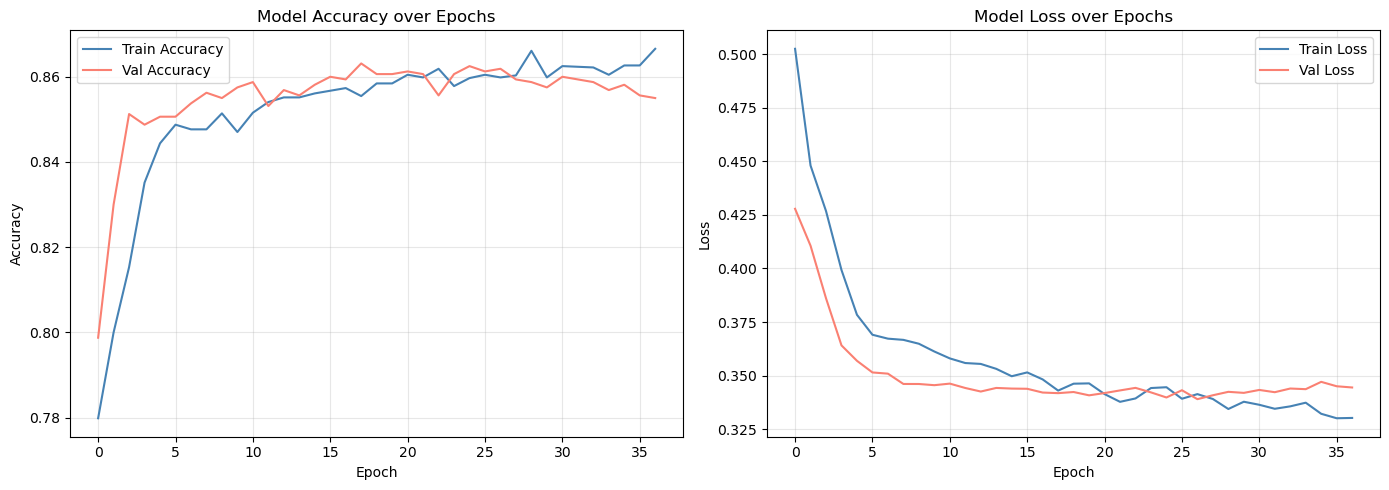

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'],
             label='Val Accuracy', color='salmon')
axes[0].set_title('Model Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],
             label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'],
             label='Val Loss', color='salmon')
axes[1].set_title('Model Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Stayed','Left']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Accuracy: 0.8585

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92      1607
        Left       0.72      0.45      0.56       393

    accuracy                           0.86      2000
   macro avg       0.80      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



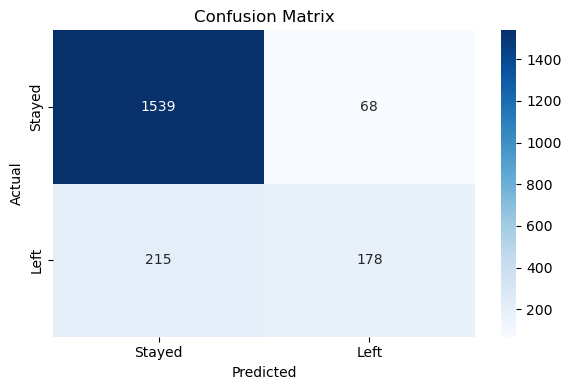

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed','Left'],
            yticklabels=['Stayed','Left'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [12]:
# Save keras model
model.save('ann_model.keras')

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save label encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("ANN model saved ✅")
print("Scaler saved ✅")
print("Label encoder saved ✅")

ANN model saved ✅
Scaler saved ✅
Label encoder saved ✅


## ✅ Summary

| Metric | Value |
|--------|-------|
| Accuracy | ~85% |
| Architecture | 64→32→16→1 |
| Activation | ReLU + Sigmoid |
| Optimizer | Adam |
| Loss | Binary Crossentropy |
| Epochs | ~40 (early stopping) |
| Training Samples | 8000 |
| Testing Samples | 2000 |

**Key concepts learned:**
- Dense layers = fully connected neurons
- ReLU activation → hidden layers (removes negatives)
- Sigmoid activation → output layer (0 to 1 probability)
- Dropout → randomly drops neurons to prevent overfitting
- Adam optimizer → adaptive learning rate
- Early stopping → stops when val_loss stops improving
- Training history plot → diagnose overfitting/underfitting

**Big difference from traditional ML:**
- No feature importance (black box)
- Needs more data to shine
- Training takes longer but handles complexity better

**Next → CNN (Convolutional Neural Network for Images!)**